In [1]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if needed

# !pip install sentence-transformers faiss-cpu torch

In [2]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import gc
import faiss
import torch

import numpy as np
import pandas as pd

from tqdm import tqdm

from sentence_transformers import SentenceTransformer

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# CELL 3 — CONFIG
# ============================================================

DATASET_PATH = "../../parquet_exports_v2/retrieval_ready_dataset_v2.parquet"

EXPORT_DIR = "../../parquet_exports_v2"

os.makedirs(EXPORT_DIR, exist_ok=True)

EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

BATCH_SIZE = 16

print("=" * 60)
print("CONFIG")
print("=" * 60)

print(f"Embedding Model : {EMBEDDING_MODEL_NAME}")
print(f"Batch Size      : {BATCH_SIZE}")

CONFIG
Embedding Model : paraphrase-multilingual-MiniLM-L12-v2
Batch Size      : 16


In [4]:
# ============================================================
# CELL 4 — DEVICE DETECTION
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("DEVICE")
print("=" * 60)

print(f"Using Device : {DEVICE}")

if DEVICE == "cuda":

    print(
        f"GPU : {torch.cuda.get_device_name(0)}"
    )

DEVICE
Using Device : cpu


In [5]:
# ============================================================
# CELL 5 — LOAD RETRIEVAL DATASET
# ============================================================

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 109,875
Columns : 11


,chunk_id,document_id,rag_id,chunk_index,chunk_text,chunk_word_count,chunk_token_estimate,bm25_tokens,metadata_json,priority_encoded,retrieval_quality_score
0,doc_0_chunk_0,doc_0,45d0726cc395d2b3a2b8c9899523e1dc,0,[PROBLEM] i am unable to access my account aft...,55,73,"[problem, i, am, unable, to, access, my, accou...","{""rag_id"": ""45d0726cc395d2b3a2b8c9899523e1dc"",...",0,2.3125
1,doc_1_chunk_0,doc_1,504f35fd3b03f048a1984f89fffb08e1,0,[PROBLEM] i would like to request a refund for...,51,68,"[problem, i, would, like, to, request, a, refu...","{""rag_id"": ""504f35fd3b03f048a1984f89fffb08e1"",...",3,1.5750
2,doc_2_chunk_0,doc_2,db7bc1e2f75fa986ee832c31e320a2de,0,[PROBLEM] there seems to be a discrepancy in m...,55,73,"[problem, there, seems, to, be, a, discrepancy...","{""rag_id"": ""db7bc1e2f75fa986ee832c31e320a2de"",...",1,3.1250
3,doc_3_chunk_0,doc_3,01d7f2addbcc200f88368695230ea06e,0,[PROBLEM] the system is not syncing data acros...,49,65,"[problem, the, system, is, not, syncing, data,...","{""rag_id"": ""01d7f2addbcc200f88368695230ea06e"",...",2,2.6125
4,doc_4_chunk_0,doc_4,aa219338e9e467aadb53d3d1a9026de7,0,[PROBLEM] i am unable to access my account aft...,53,70,"[problem, i, am, unable, to, access, my, accou...","{""rag_id"": ""aa219338e9e467aadb53d3d1a9026de7"",...",2,2.9500


In [6]:
# ============================================================
# CELL 6 — VALIDATE CHUNK TEXT
# ============================================================

TEXT_COLUMN = "chunk_text"

empty_chunks = (
    df[TEXT_COLUMN]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("=" * 60)
print("CHUNK VALIDATION")
print("=" * 60)

print(f"Empty chunks : {empty_chunks:,}")

CHUNK VALIDATION
Empty chunks : 0


In [7]:
# ============================================================
# CELL 7 — REMOVE INVALID CHUNKS
# ============================================================

before_rows = len(df)

df = df[
    df[TEXT_COLUMN]
    .fillna("")
    .str.strip()
    != ""
].copy()

removed_rows = before_rows - len(df)

print("=" * 60)
print("INVALID CHUNK FILTER")
print("=" * 60)

print(f"Removed rows : {removed_rows:,}")
print(f"Remaining    : {len(df):,}")

INVALID CHUNK FILTER
Removed rows : 0
Remaining    : 109,875


In [8]:
# ============================================================
# CELL 8 — LOAD EMBEDDING MODEL
# ============================================================

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device=DEVICE
)

print("=" * 60)
print("MODEL LOADED")
print("=" * 60)

print(f"Model : {EMBEDDING_MODEL_NAME}")

MODEL LOADED
Model : paraphrase-multilingual-MiniLM-L12-v2


In [9]:
# ============================================================
# CELL 9 — GENERATE EMBEDDINGS
# ============================================================

texts = df[TEXT_COLUMN].tolist()

print("=" * 60)
print("GENERATING EMBEDDINGS")
print("=" * 60)

print(f"Documents : {len(texts):,}")

embeddings = embedding_model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

embeddings = embeddings.astype("float32")

print("=" * 60)
print("EMBEDDINGS GENERATED")
print("=" * 60)

print(f"Embedding Shape : {embeddings.shape}")

GENERATING EMBEDDINGS
Documents : 109,875


Batches:   0%|          | 0/6868 [00:00<?, ?it/s]

EMBEDDINGS GENERATED
Embedding Shape : (109875, 384)


In [10]:
# ============================================================
# CELL 10 — EMBEDDING STATISTICS
# ============================================================

print("=" * 60)
print("EMBEDDING STATISTICS")
print("=" * 60)

print(f"Vector Count     : {embeddings.shape[0]:,}")

print(f"Vector Dimension : {embeddings.shape[1]}")

print(f"Embedding Size   : {embeddings.nbytes / 1024**2:.2f} MB")

EMBEDDING STATISTICS
Vector Count     : 109,875
Vector Dimension : 384
Embedding Size   : 160.95 MB


In [11]:
# ============================================================
# CELL 11 — BUILD FAISS INDEX
# ============================================================

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

faiss.normalize_L2(embeddings)

index.add(embeddings)

print("=" * 60)
print("FAISS INDEX CREATED")
print("=" * 60)

print(f"Index Size       : {index.ntotal:,}")

print(f"Vector Dimension : {dimension}")

FAISS INDEX CREATED
Index Size       : 109,875
Vector Dimension : 384


In [12]:
# ============================================================
# CELL 12 — PROBLEM-TO-RESOLUTION SEMANTIC SEARCH
# ============================================================

def problem_to_resolution_search(
    query: str,
    top_k: int = 5
):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    scores, indices = index.search(
        query_embedding,
        top_k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        row = df.iloc[idx]

        results.append({
            "chunk_id": row["chunk_id"],
            "rag_id": row.get("rag_id"),
            "score": float(score),
            "text": row["chunk_text"]
        })

    return pd.DataFrame(results)


print("problem_to_resolution_search function created.")

problem_to_resolution_search function created.


In [13]:
# ============================================================
# CELL 13 — TEST PROBLEM-TO-RESOLUTION SEARCH
# ============================================================

query = "VPN connection fails after password reset"

results = problem_to_resolution_search(
    query=query,
    top_k=5
)

print("=" * 60)
print("PROBLEM-TO-RESOLUTION SEARCH RESULTS")
print("=" * 60)

results

PROBLEM-TO-RESOLUTION SEARCH RESULTS


,chunk_id,rag_id,score,text
0,doc_86071_chunk_0,f9869bf85ba471f62a745e01355ab4ca,0.618192,[PROBLEM] vpn connection issue team n nwe are ...
1,doc_37685_chunk_0,c0dd0902136d5bb908d7f0b9fc6ac0ad,0.596703,[PROBLEM] vpn access issue customer support n ...
2,doc_103215_chunk_0,60d6d0c0042a5a04dc40a0328011dac0,0.553104,[PROBLEM] problem with vpn our marketing agenc...
3,doc_42038_chunk_0,4ecf85ce7f08236be89f3c4ef38a72dc,0.543521,[PROBLEM] login problem with user accounts the...
4,doc_23521_chunk_0,99af08b63fa648528dc665b88af6335f,0.536279,[PROBLEM] trouble with logins after recent sys...


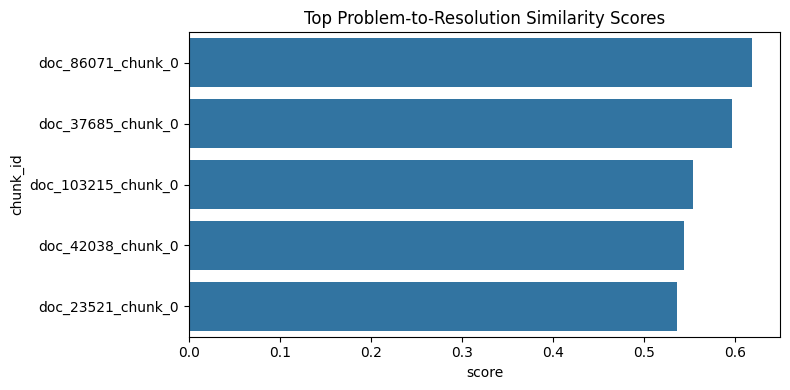

In [14]:
# ============================================================
# CELL 14 — VISUALIZE SIMILARITY SCORES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.barplot(
    data=results,
    x="score",
    y="chunk_id"
)

plt.title("Top Problem-to-Resolution Similarity Scores")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELL 15 — EXPORT FAISS INDEX
# ============================================================

FAISS_INDEX_PATH = (
    f"{EXPORT_DIR}/incident_resolution.index"
)

faiss.write_index(
    index,
    FAISS_INDEX_PATH
)

print("=" * 60)
print("FAISS INDEX EXPORTED")
print("=" * 60)

print(f"Path:\n{FAISS_INDEX_PATH}")

FAISS INDEX EXPORTED
Path:
../../parquet_exports_v2/incident_resolution.index


In [16]:
# ============================================================
# CELL 16 — EXPORT EMBEDDINGS
# ============================================================

EMBEDDINGS_PATH = (
    f"{EXPORT_DIR}/embeddings.npy"
)

np.save(
    EMBEDDINGS_PATH,
    embeddings
)

print("=" * 60)
print("EMBEDDINGS EXPORTED")
print("=" * 60)

print(f"Path:\n{EMBEDDINGS_PATH}")

EMBEDDINGS EXPORTED
Path:
../../parquet_exports_v2/embeddings.npy


In [17]:
# ============================================================
# CELL 17 — EXPORT EMBEDDING METADATA
# ============================================================

METADATA_COLUMNS = [
    c for c in [
        "chunk_id",
        "document_id",
        "rag_id",
        "chunk_text",
        "metadata_json",
        "priority_encoded",
        "retrieval_quality_score"
    ]
    if c in df.columns
]

metadata_df = (
    df[METADATA_COLUMNS]
    .copy()
)

METADATA_PATH = (
    f"{EXPORT_DIR}/embedding_metadata.parquet"
)

metadata_df.to_parquet(
    METADATA_PATH,
    index=False
)

print("=" * 60)
print("METADATA EXPORTED")
print("=" * 60)

print(f"Path:\n{METADATA_PATH}")

METADATA EXPORTED
Path:
../../parquet_exports_v2/embedding_metadata.parquet


In [18]:
# ============================================================
# CELL 18 — VECTOR SEARCH LATENCY TEST
# ============================================================

import time

test_query = "VPN connection fails after password reset"

start_time = time.perf_counter()

_ = problem_to_resolution_search(
    query=test_query,
    top_k=5
)

latency_ms = (
    (time.perf_counter() - start_time)
    * 1000
)

print("=" * 60)
print("VECTOR SEARCH LATENCY")
print("=" * 60)

print(f"Latency : {latency_ms:.2f} ms")

VECTOR SEARCH LATENCY
Latency : 122.65 ms


In [ ]:
# ============================================================
# CELL 19 — FINAL VECTOR REPORT
# ============================================================

print("=" * 60)
print("FINAL VECTOR REPORT")
print("=" * 60)

print(f"Total Chunks             : {len(df):,}")

print(f"Embedding Dimension      : {embeddings.shape[1]}")

print(f"FAISS Index Size         : {index.ntotal:,}")

print(f"Embedding Memory         : {embeddings.nbytes / 1024**2:.2f} MB")

print(f"Average Retrieval Score  : {results['score'].mean():.4f}")

FINAL VECTOR REPORT


NameError: name 'df' is not defined

In [20]:
# ============================================================
# CELL 20 — CLEANUP MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

print("=" * 60)
print("MEMORY CLEANUP COMPLETED")
print("=" * 60)

MEMORY CLEANUP COMPLETED
